In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from gwpy.timeseries import TimeSeries
from scipy.ndimage import uniform_filter1d

import seaborn as sns
sns.set(style='whitegrid', context='paper')

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
# Load colored time domain data for H1 and L1
data_dir = Path('/home/x-ctirapongpra/scratch/gw-collapsar/two_detectors_output/bayeswave_output_0/data')
frame_dir = Path('/home/x-ctirapongpra/scratch/gw-collapsar/Frames')

def load_colored_time_domain_data(filepath):
    """Load colored time domain data file, skipping the header."""
    with open(filepath, 'r') as f:
        # Skip header lines until we find the data separator
        for line in f:
            if line.strip() == '---------------':
                break
        # Skip the column header line
        next(f)
        # Read the data
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)

# Load H1 and L1 BayesWave colored data
h1_data_file = data_dir / 'colored_time_domain_data_H1.dat'
l1_data_file = data_dir / 'colored_time_domain_data_L1.dat'

h1_data = load_colored_time_domain_data(h1_data_file)
l1_data = load_colored_time_domain_data(l1_data_file)

# Load whitened time domain data
h1_whitened_file = data_dir / 'whitened_time_domain_data_H1.dat'
l1_whitened_file = data_dir / 'whitened_time_domain_data_L1.dat'

h1_whitened = load_colored_time_domain_data(h1_whitened_file)
l1_whitened = load_colored_time_domain_data(l1_whitened_file)

In [3]:
# Load noise PSD data
def load_psd_data(filepath):
    """Load PSD data file, skipping the header."""
    with open(filepath, 'r') as f:
        # Skip header lines until we find the data separator
        for line in f:
            if line.strip() == '---------------':
                break
        # Skip the column header line
        next(f)
        # Read the data
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)

h1_psd_file = data_dir / 'noise_psd_H1.dat'
l1_psd_file = data_dir / 'noise_psd_L1.dat'

h1_psd = load_psd_data(h1_psd_file)
l1_psd = load_psd_data(l1_psd_file)

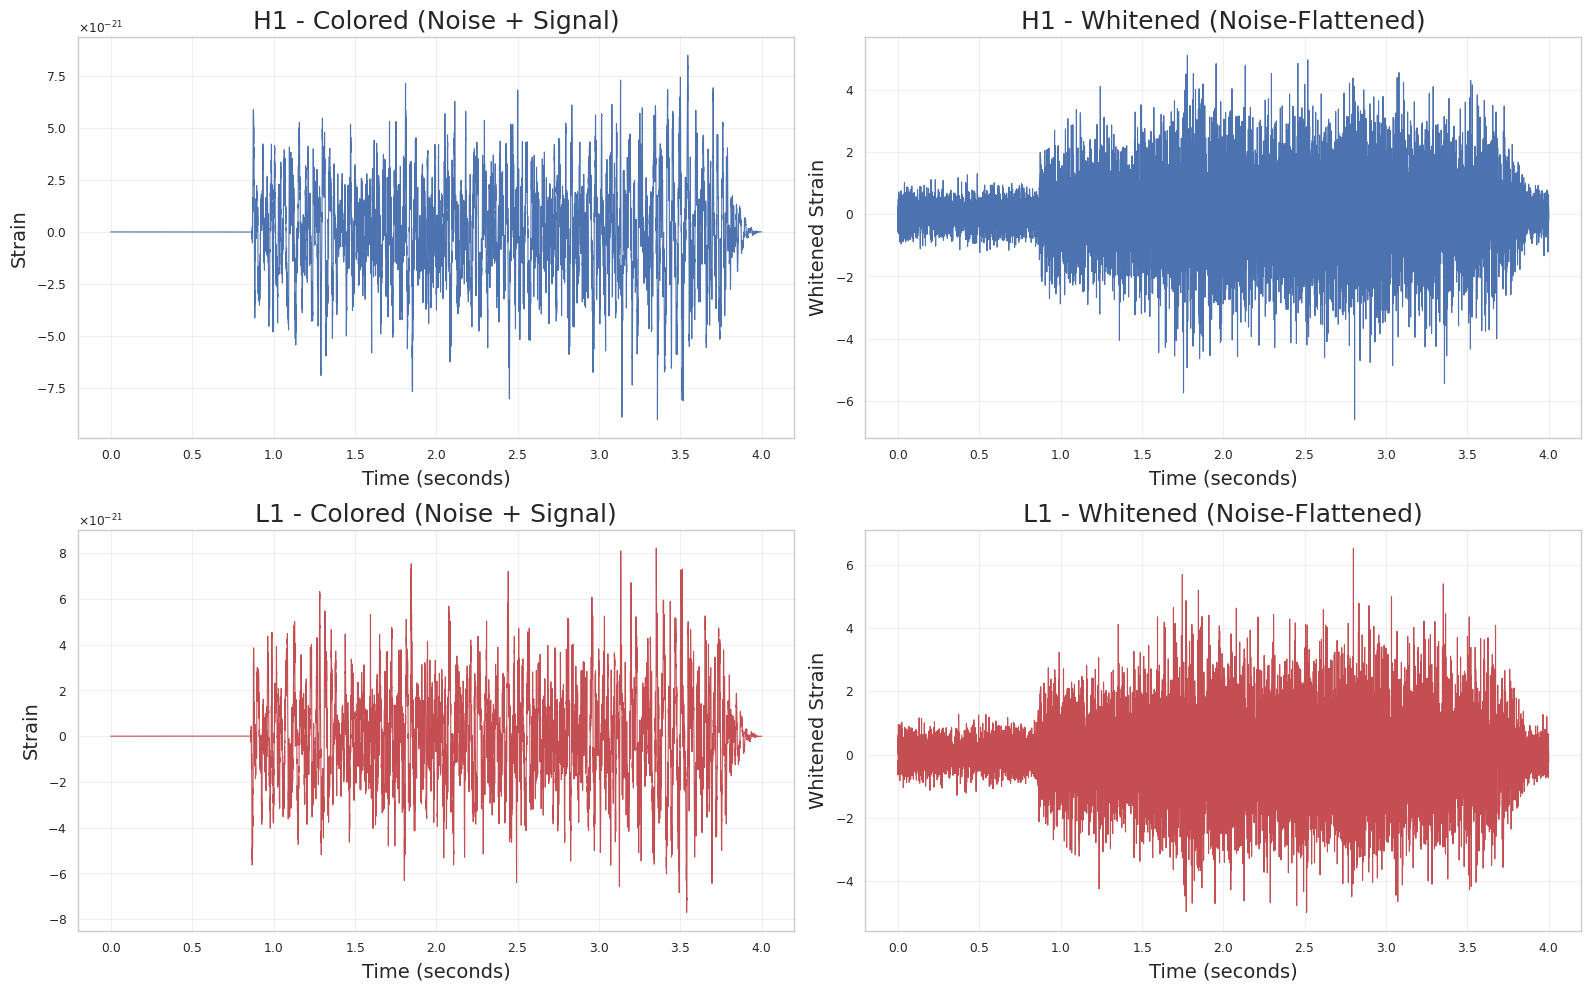

In [4]:
# Plot whitened vs colored data for H1 and L1
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# H1 Colored
ax1.plot(h1_data[:, 0], h1_data[:, 1], 'b-', linewidth=0.8)
ax1.set_ylabel('Strain', fontsize=14)
ax1.set_title('H1 - Colored (Noise + Signal)', fontsize=18)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Time (seconds)', fontsize=14)

# H1 Whitened
ax2.plot(h1_whitened[:, 0], h1_whitened[:, 1], 'b-', linewidth=0.8)
ax2.set_ylabel('Whitened Strain', fontsize=14)
ax2.set_title('H1 - Whitened (Noise-Flattened)', fontsize=18)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Time (seconds)', fontsize=14)

# L1 Colored
ax3.plot(l1_data[:, 0], l1_data[:, 1], 'r-', linewidth=0.8)
ax3.set_ylabel('Strain', fontsize=14)
ax3.set_title('L1 - Colored (Noise + Signal)', fontsize=18)
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Time (seconds)', fontsize=14)

# L1 Whitened
ax4.plot(l1_whitened[:, 0], l1_whitened[:, 1], 'r-', linewidth=0.8)
ax4.set_ylabel('Whitened Strain', fontsize=14)
ax4.set_title('L1 - Whitened (Noise-Flattened)', fontsize=18)
ax4.grid(True, alpha=0.3)
ax4.set_xlabel('Time (seconds)', fontsize=14)

plt.tight_layout()
plt.show()

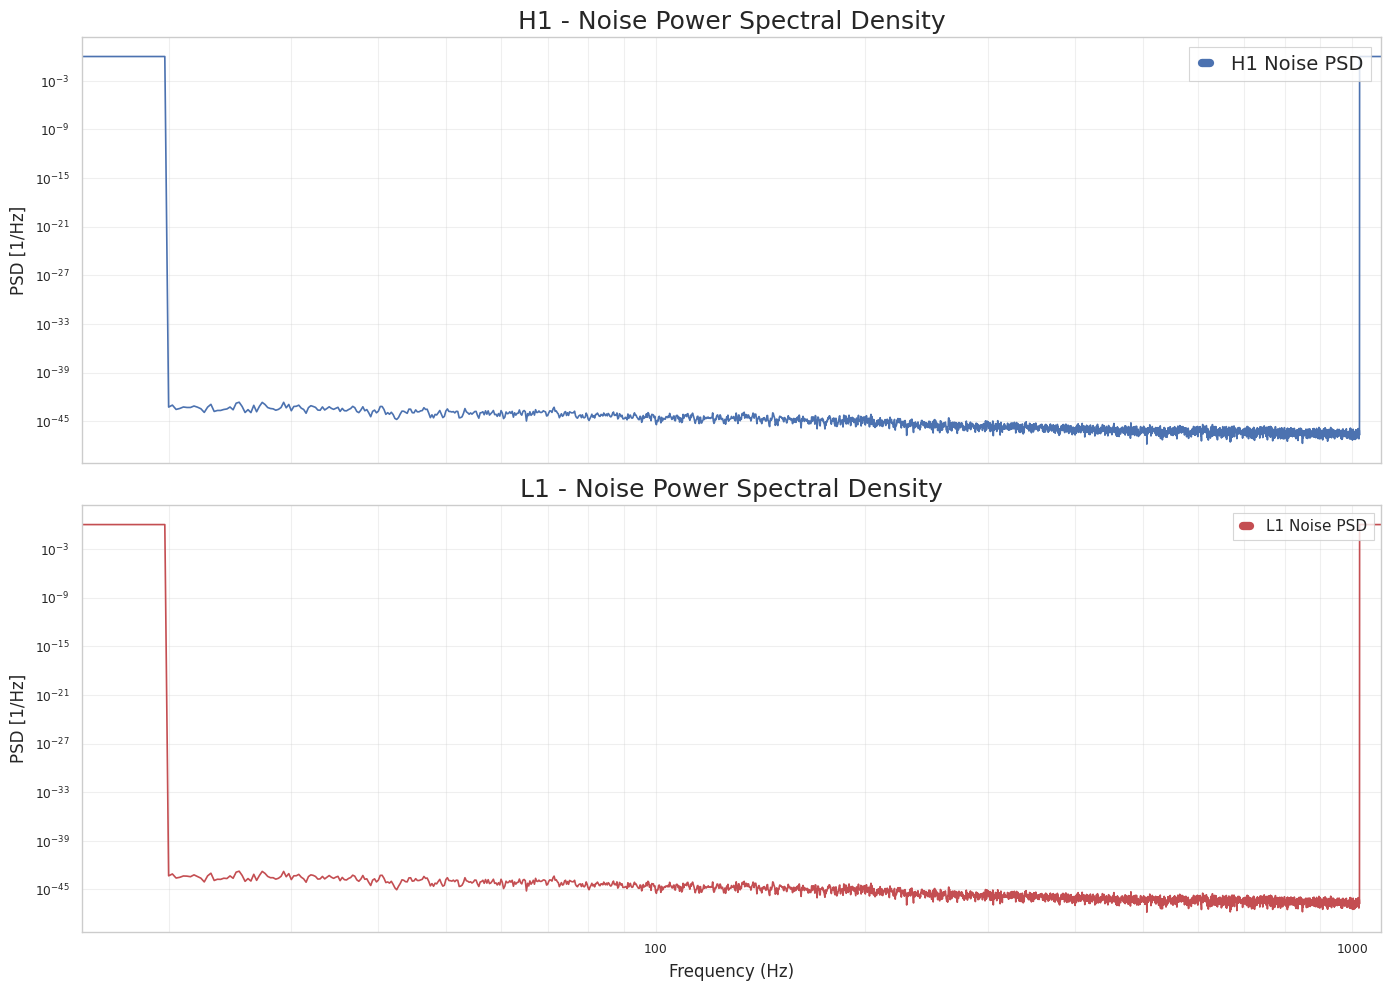

In [5]:
# Plot noise PSD for H1 and L1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot H1 PSD
ax1.loglog(h1_psd[:, 0], h1_psd[:, 1], 'b-', linewidth=1.2, label='H1 Noise PSD')
ax1.set_ylabel('PSD [1/Hz]', fontsize=12)
ax1.set_title('H1 - Noise Power Spectral Density', fontsize=18)
ax1.legend(loc='upper right', fontsize=14)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(15, 1100)

# Plot L1 PSD
ax2.loglog(l1_psd[:, 0], l1_psd[:, 1], 'r-', linewidth=1.2, label='L1 Noise PSD')
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('PSD [1/Hz]', fontsize=12)
ax2.set_title('L1 - Noise Power Spectral Density', fontsize=18)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(15, 1100)

plt.tight_layout()
plt.show()

In [6]:
def detect_signal_jump_gradient(time, strain, smooth_window=50, threshold_percentile=99):
    """
    Detect signal jump by finding where the gradient of the envelope increases sharply.
    
    Parameters:
    -----------
    time : array
        Time values
    strain : array
        Strain amplitude values
    smooth_window : int
        Window size for smoothing the envelope
    threshold_percentile : float
        Percentile of gradient to use as threshold
    
    Returns:
    --------
    jump_time : float
        Time where the jump is detected
    jump_idx : int
        Index where the jump is detected
    """
    # Calculate envelope (absolute value)
    envelope = np.abs(strain)
    
    # Smooth the envelope
    smoothed_envelope = uniform_filter1d(envelope, size=smooth_window)
    
    # Calculate gradient
    gradient = np.gradient(smoothed_envelope)
    
    # Find threshold based on baseline gradient
    baseline_end = int(0.3 * len(gradient))
    threshold = np.percentile(gradient[baseline_end:], threshold_percentile)
    
    # Find first point exceeding threshold
    jump_indices = np.where(gradient > threshold)[0]
    
    if len(jump_indices) > 0:
        jump_idx = jump_indices[0]
        jump_time = time[jump_idx]
        return jump_time, jump_idx, smoothed_envelope, gradient
    else:
        return None, None, smoothed_envelope, gradient


# H1 Detection
h1_time = h1_data[:, 0]
h1_strain = h1_data[:, 1]

h1_jump_time, h1_jump_idx, h1_envelope, h1_gradient = detect_signal_jump_gradient(h1_time, h1_strain)

print(f"\nH1 Detector: Jump detected at t = {h1_jump_time:.3f} s")

# L1 Detection
l1_time = l1_data[:, 0]
l1_strain = l1_data[:, 1]

l1_jump_time, l1_jump_idx, l1_envelope, l1_gradient = detect_signal_jump_gradient(l1_time, l1_strain)

print(f"L1 Detector: Jump detected at t = {l1_jump_time:.3f} s")


H1 Detector: Jump detected at t = 0.869 s
L1 Detector: Jump detected at t = 0.862 s


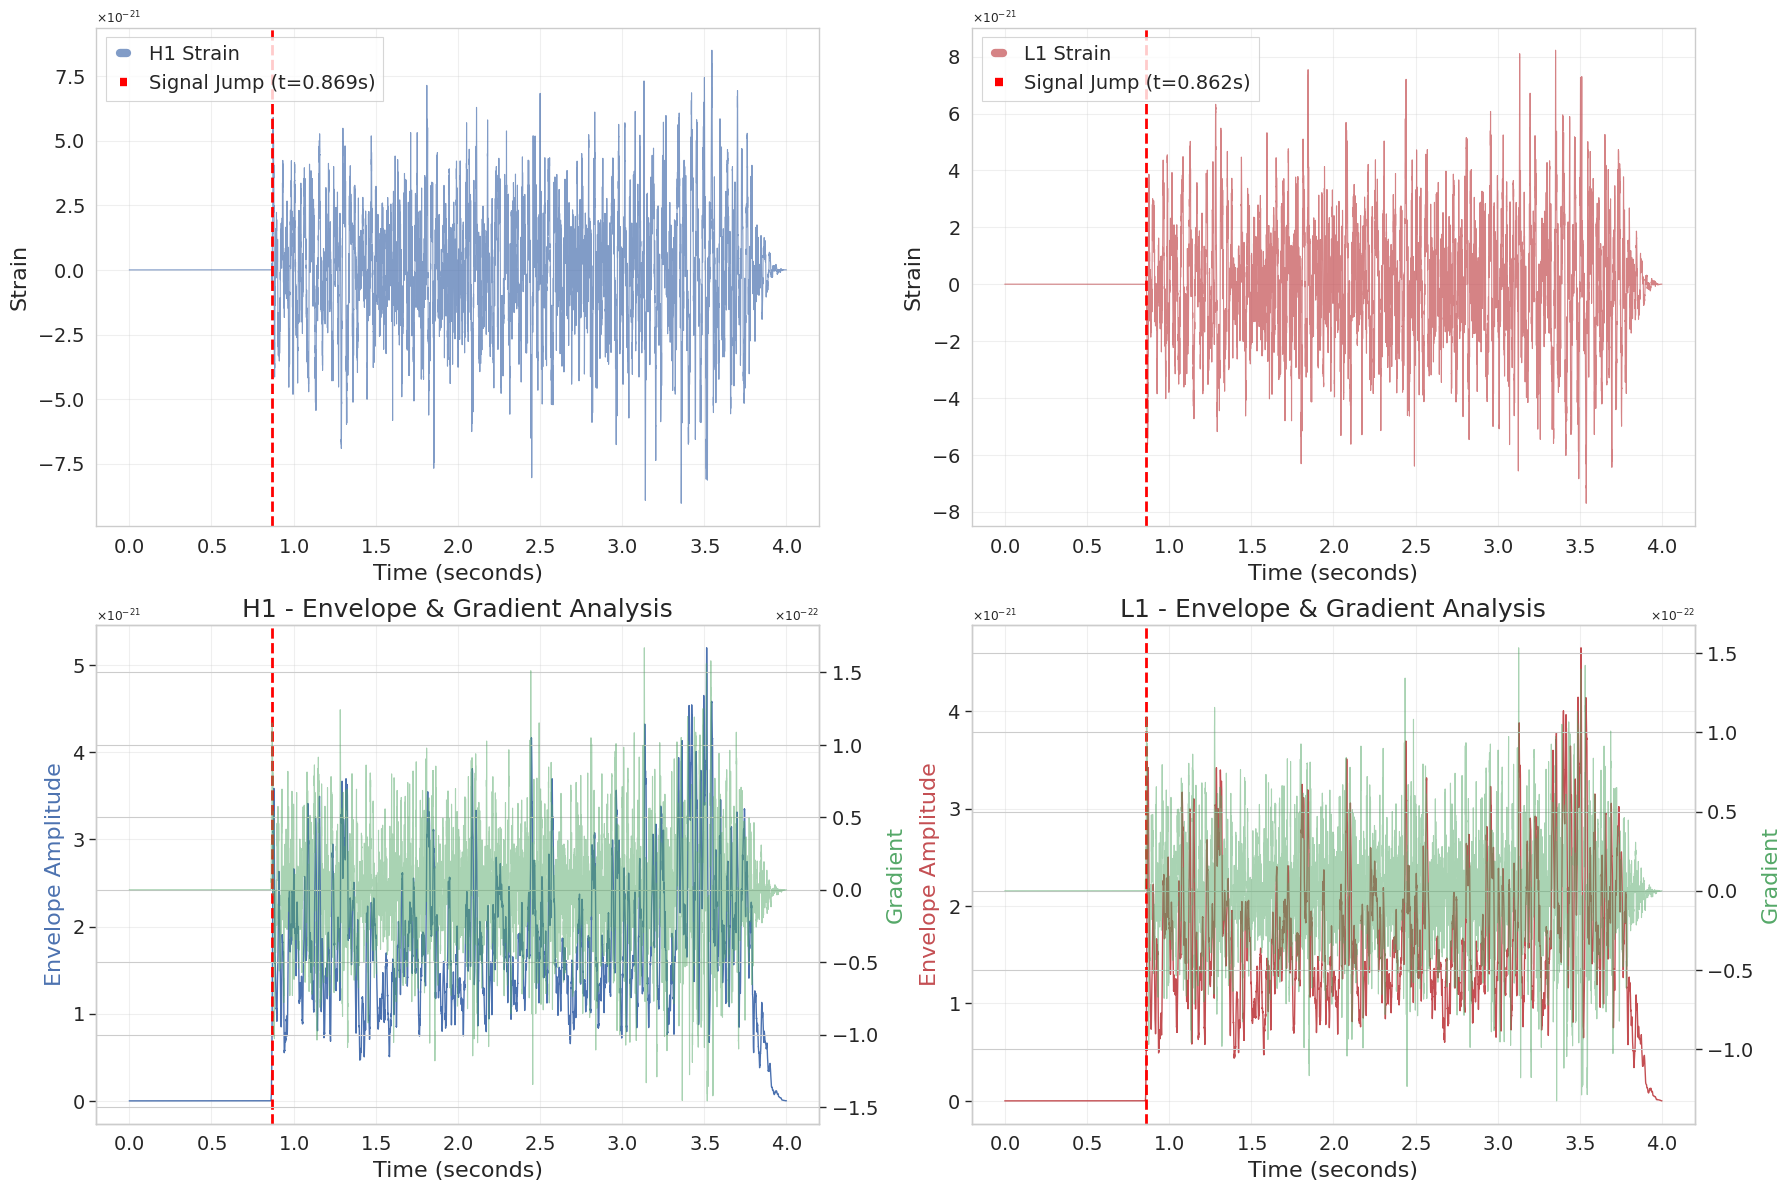

In [7]:
# Visualize the detected jump points
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# H1 Colored with detection marker
ax1.plot(h1_time, h1_strain, 'b-', linewidth=0.8, alpha=0.7, label='H1 Strain')
if h1_jump_time is not None:
    ax1.axvline(h1_jump_time, color='red', linestyle='--', linewidth=2, 
                label=f'Signal Jump (t={h1_jump_time:.3f}s)')
ax1.set_ylabel('Strain', fontsize=16)
ax1.set_xlabel('Time (seconds)', fontsize=16)
ax1.legend(loc='upper left', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=14)

# L1 Colored with detection marker
ax2.plot(l1_time, l1_strain, 'r-', linewidth=0.8, alpha=0.7, label='L1 Strain')
if l1_jump_time is not None:
    ax2.axvline(l1_jump_time, color='red', linestyle='--', linewidth=2, 
                label=f'Signal Jump (t={l1_jump_time:.3f}s)')
ax2.set_ylabel('Strain', fontsize=16)
ax2.set_xlabel('Time (seconds)', fontsize=16)
ax2.legend(loc='upper left', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=14)

# H1 Envelope with gradient
ax3.plot(h1_time, h1_envelope, 'b-', linewidth=1, label='Smoothed Envelope')
ax3_twin = ax3.twinx()
ax3_twin.plot(h1_time, h1_gradient, 'g-', linewidth=0.8, alpha=0.5, label='Gradient')
if h1_jump_time is not None:
    ax3.axvline(h1_jump_time, color='red', linestyle='--', linewidth=2)
ax3.set_ylabel('Envelope Amplitude', fontsize=16, color='b')
ax3_twin.set_ylabel('Gradient', fontsize=16, color='g')
ax3.set_xlabel('Time (seconds)', fontsize=16)
ax3.set_title('H1 - Envelope & Gradient Analysis', fontsize=18)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3_twin.tick_params(axis='y', which='major', labelsize=14)

# L1 Envelope with gradient
ax4.plot(l1_time, l1_envelope, 'r-', linewidth=1, label='Smoothed Envelope')
ax4_twin = ax4.twinx()
ax4_twin.plot(l1_time, l1_gradient, 'g-', linewidth=0.8, alpha=0.5, label='Gradient')
if l1_jump_time is not None:
    ax4.axvline(l1_jump_time, color='red', linestyle='--', linewidth=2)
ax4.set_ylabel('Envelope Amplitude', fontsize=16, color='r')
ax4_twin.set_ylabel('Gradient', fontsize=16, color='g')
ax4.set_xlabel('Time (seconds)', fontsize=16)
ax4.set_title('L1 - Envelope & Gradient Analysis', fontsize=18)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='both', which='major', labelsize=14)
ax4_twin.tick_params(axis='y', which='major', labelsize=14)

plt.tight_layout()
plt.show()

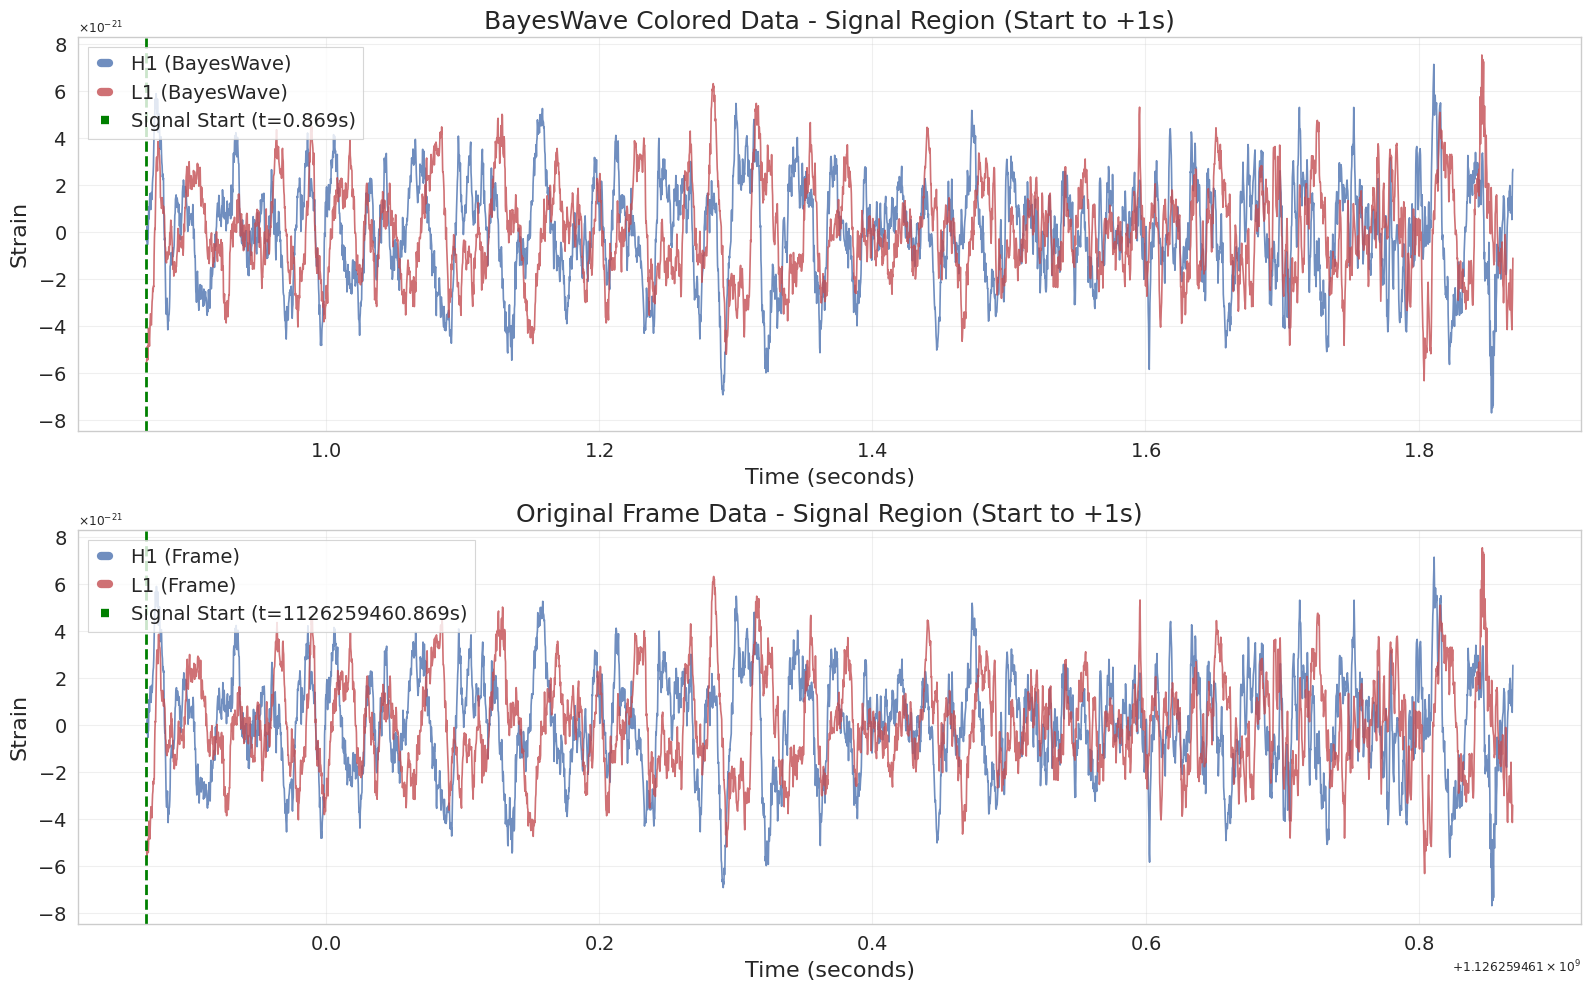

In [8]:
# Create zoomed-in plot of signal detection
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# First subplot: BayesWave colored data - zoomed to signal + 1 second
if h1_jump_time is not None:
    # Define time window: from signal start to 1 second after
    t_start = h1_jump_time
    t_end = h1_jump_time + 1.0
    
    # Find indices for this time window
    h1_mask = (h1_time >= t_start) & (h1_time <= t_end)
    l1_mask = (l1_time >= t_start) & (l1_time <= t_end)
    
    ax1.plot(h1_time[h1_mask], h1_strain[h1_mask], 'b-', linewidth=1.2, alpha=0.8, label='H1 (BayesWave)')
    ax1.plot(l1_time[l1_mask], l1_strain[l1_mask], 'r-', linewidth=1.2, alpha=0.8, label='L1 (BayesWave)')
    ax1.axvline(h1_jump_time, color='green', linestyle='--', linewidth=2, label=f'Signal Start (t={h1_jump_time:.3f}s)')
    
ax1.set_ylabel('Strain', fontsize=16)
ax1.set_xlabel('Time (seconds)', fontsize=16)
ax1.set_title('BayesWave Colored Data - Signal Region (Start to +1s)', fontsize=18)
ax1.legend(loc='upper left', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=14)

# Second subplot: Original frame data - zoomed to signal region
# Load the frame files

h1_frame = TimeSeries.read(frame_dir / 'H1.gwf', 'H1:GW-H')
l1_frame = TimeSeries.read(frame_dir / 'L1.gwf', 'L1:GW-L')

# Detect signal in frame data using the same method
h1_frame_time = h1_frame.times.value
h1_frame_strain = h1_frame.value

l1_frame_time = l1_frame.times.value
l1_frame_strain = l1_frame.value

# Detect jump in frame data
h1_frame_jump_time, h1_frame_jump_idx, _, _ = detect_signal_jump_gradient(h1_frame_time, h1_frame_strain)

if h1_frame_jump_time is not None:
    # Define time window: from signal start to 1 second after
    frame_t_start = h1_frame_jump_time
    frame_t_end = h1_frame_jump_time + 1.0
    
    # Find indices for this time window
    h1_frame_mask = (h1_frame_time >= frame_t_start) & (h1_frame_time <= frame_t_end)
    l1_frame_mask = (l1_frame_time >= frame_t_start) & (l1_frame_time <= frame_t_end)
    
    ax2.plot(h1_frame_time[h1_frame_mask], h1_frame_strain[h1_frame_mask], 'b-', linewidth=1.2, alpha=0.8, label='H1 (Frame)')
    ax2.plot(l1_frame_time[l1_frame_mask], l1_frame_strain[l1_frame_mask], 'r-', linewidth=1.2, alpha=0.8, label='L1 (Frame)')
    ax2.axvline(h1_frame_jump_time, color='green', linestyle='--', linewidth=2, label=f'Signal Start (t={h1_frame_jump_time:.3f}s)')

ax2.set_ylabel('Strain', fontsize=16)
ax2.set_xlabel('Time (seconds)', fontsize=16)
ax2.set_title('Original Frame Data - Signal Region (Start to +1s)', fontsize=18)
ax2.legend(loc='upper left', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()